In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

DATA_DIR = "/content/drive/MyDrive/data1"

import os


if os.path.exists(DATA_DIR):
    print("✅ Success! Colab found your data folder.")
    print("Folders detected:", os.listdir(DATA_DIR))
else:
    print("❌ Error: Path not found. Double-check your copy-paste!")

✅ Success! Colab found your data folder.
Folders detected: ['validation', 'test', 'train']


Device: cuda

Training: densenet121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 131MB/s]


Epoch 1/10 | Train Acc: 0.9469 | Val Acc: 0.9631
Epoch 2/10 | Train Acc: 0.9612 | Val Acc: 0.9726
Epoch 3/10 | Train Acc: 0.9704 | Val Acc: 0.9488
Epoch 4/10 | Train Acc: 0.9750 | Val Acc: 0.9750
Epoch 5/10 | Train Acc: 0.9750 | Val Acc: 0.9548
Epoch 6/10 | Train Acc: 0.9847 | Val Acc: 0.9607
Epoch 7/10 | Train Acc: 0.9694 | Val Acc: 0.9631
Epoch 8/10 | Train Acc: 0.9724 | Val Acc: 0.9714
Epoch 9/10 | Train Acc: 0.9842 | Val Acc: 0.9762
Epoch 10/10 | Train Acc: 0.9811 | Val Acc: 0.9571
Saved: /content/drive/MyDrive/models1/tumor_densenet121.pth


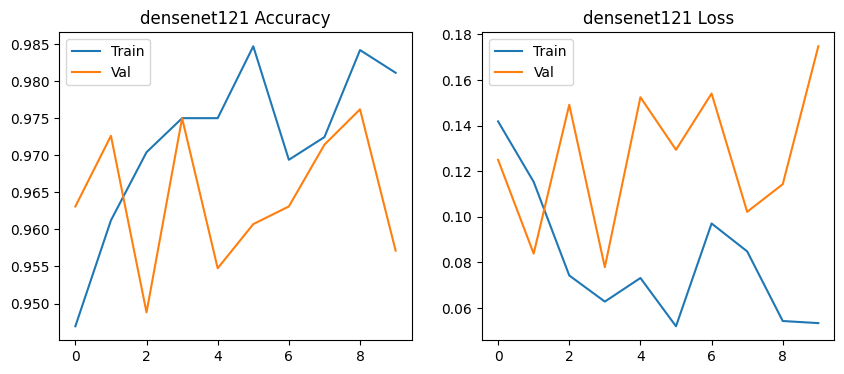


Training: resnet50
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 156MB/s]


Epoch 1/10 | Train Acc: 0.9383 | Val Acc: 0.7798
Epoch 2/10 | Train Acc: 0.9704 | Val Acc: 0.9417
Epoch 3/10 | Train Acc: 0.9699 | Val Acc: 0.9810
Epoch 4/10 | Train Acc: 0.9694 | Val Acc: 0.9631
Epoch 5/10 | Train Acc: 0.9806 | Val Acc: 0.9786
Epoch 6/10 | Train Acc: 0.9786 | Val Acc: 0.9821
Epoch 7/10 | Train Acc: 0.9934 | Val Acc: 0.9798
Epoch 8/10 | Train Acc: 0.9908 | Val Acc: 0.9798
Epoch 9/10 | Train Acc: 0.9888 | Val Acc: 0.9631
Epoch 10/10 | Train Acc: 0.9878 | Val Acc: 0.9762
Saved: /content/drive/MyDrive/models1/tumor_resnet50.pth


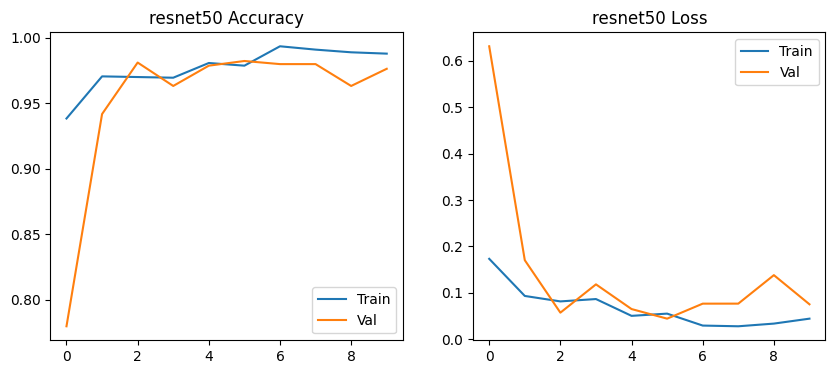


Training Complete.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import copy
from google.colab import drive

SAVE_DIR = "/content/drive/MyDrive/models1"
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# 1. CONFIG
# =========================
MODELS_TO_TRAIN = ["densenet121", "resnet50"]
EPOCHS = 10
BATCH_SIZE = 32
LR = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

# 2. DATA

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

image_datasets = {
    "train": datasets.ImageFolder(os.path.join(DATA_DIR, "train"), train_transform),
    "validation": datasets.ImageFolder(os.path.join(DATA_DIR, "validation"), val_transform),
    "test": datasets.ImageFolder(os.path.join(DATA_DIR, "test"), val_transform),
}

loaders = {
    "train": DataLoader(image_datasets["train"], batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True),
    "validation": DataLoader(image_datasets["validation"], batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True),
    "test": DataLoader(image_datasets["test"], batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True),
}

dataset_sizes = {x: len(image_datasets[x]) for x in image_datasets}
class_names = image_datasets["train"].classes

# 3. MODEL BUILDER

def build_model(name, num_classes):
    if name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif name == "densenet121":
        model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    else:
        raise ValueError("Invalid model name")
    return model.to(DEVICE)

# 4. TRAINING LOOP

for model_name in MODELS_TO_TRAIN:

    print("\n" + "=" * 40)
    print("Training:", model_name)
    print("=" * 40)

    model = build_model(model_name, len(class_names))
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    history = {
        "train_acc": [],
        "val_acc": [],
        "train_loss": [],
        "val_loss": []
    }

    for epoch in range(EPOCHS):

        for phase in ["train", "validation"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_correct = 0

            for inputs, labels in loaders[phase]:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_correct += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = (running_correct.double() / dataset_sizes[phase]).item()

            # Save history
            if phase == "train":
                history["train_loss"].append(epoch_loss)
                history["train_acc"].append(epoch_acc)
            else:
                history["val_loss"].append(epoch_loss)
                history["val_acc"].append(epoch_acc)

                # Save best model
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_weights = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"Train Acc: {history['train_acc'][-1]:.4f} | "
              f"Val Acc: {history['val_acc'][-1]:.4f}")

    # =========================
    # 5. SAVE MODEL (FIXED PATH)
    # =========================
    model.load_state_dict(best_weights)

    save_path = os.path.join(SAVE_DIR, f"tumor_{model_name}.pth")
    torch.save({
        "model_state_dict": model.state_dict(),
        "class_to_idx": image_datasets["train"].class_to_idx,
        "model_name": model_name
    }, save_path)

    print("Saved:", save_path)

    # =========================
    # 6. PLOT
    # =========================
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(history["train_acc"], label="Train")
    plt.plot(history["val_acc"], label="Val")
    plt.title(f"{model_name} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history["train_loss"], label="Train")
    plt.plot(history["val_loss"], label="Val")
    plt.title(f"{model_name} Loss")
    plt.legend()

    plt.show()

print("\nTraining Complete.")

In [5]:
def test_all_models():
    test_loader = loaders['test']

    for m_name in MODELS_TO_TRAIN:
        print(f"\n--- Testing {m_name} ---")

        model = build_model(m_name, len(class_names))
        checkpoint = torch.load(
            f"/content/drive/MyDrive/models1/tumor_{m_name}.pth",
            map_location=DEVICE
        )

        model.load_state_dict(checkpoint['model_state_dict'])
        model = model.to(DEVICE)
        model.eval()

        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)

                running_corrects += (preds == labels).sum().item()

        final_acc = running_corrects / len(test_loader.dataset)
        print(f"Final Test Accuracy for {m_name}: {final_acc:.4f}")

test_all_models()



--- Testing densenet121 ---
Final Test Accuracy for densenet121: 0.9200

--- Testing resnet50 ---
Final Test Accuracy for resnet50: 0.9450


In [6]:
from PIL import Image
import torch.nn.functional as F

def predict_single_image(image_path, model_name):

    img = Image.open(image_path).convert("RGB")
    img_tensor = val_transform(img).unsqueeze(0).to(DEVICE)

    model = build_model(model_name, len(class_names))
    checkpoint = torch.load(
        f"/content/drive/MyDrive/models/tumor_{model_name}.pth",
        map_location=DEVICE
    )

    model.load_state_dict(checkpoint['model_state_dict'])
    model = model.to(DEVICE)
    model.eval()

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)[0]
        confidence, predicted_idx = torch.max(probs, 0)

    result = class_names[predicted_idx.item()]
    print(f"[{model_name}] Prediction: {result} | Confidence: {confidence.item():.4f}")

In [8]:


def build_model(name, num_classes):
    if name == "resnet50":
        model = models.resnet50(weights=None)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    else:
        model = models.densenet121(weights=None)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model

m_name = "resnet50"

checkpoint = torch.load(
    f"/content/drive/MyDrive/models1/tumor_{m_name}.pth",
    map_location=DEVICE
)

model = build_model(m_name, 2)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:

def getClippingBounds(mean, std, device):
    meanT = torch.tensor(mean).view(1, 3, 1, 1).to(device)
    stdT = torch.tensor(std).view(1, 3, 1, 1).to(device)

    return (0 - meanT) / stdT, (1 - meanT) / stdT


def fgsm_attack(model, image, label, epsilon, min_clip, max_clip):
    model.eval()

    image_adv = image.clone().detach().requires_grad_(True)

    output = model(image_adv)
    loss = nn.CrossEntropyLoss()(output, label)

    model.zero_grad()
    loss.backward()

    grad_sign = image_adv.grad.sign()

    attacked = image_adv + epsilon * grad_sign

    attacked = torch.max(torch.min(attacked, max_clip), min_clip)

    return attacked.detach()

In [10]:
min_clip, max_clip = getClippingBounds(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225],
    device=DEVICE
)

In [11]:
dataiter = iter(loaders["test"])
image, label = next(dataiter)

image = image[0].unsqueeze(0).to(DEVICE)
label = label[0].unsqueeze(0).to(DEVICE)

In [12]:
with torch.no_grad():
    output = model(image)
    _, pred = torch.max(output, 1)

print("Clean prediction:", pred.item())

Clean prediction: 0


In [13]:
adv_image = fgsm_attack(
    model,
    image,
    label,
    epsilon=0.01,
    min_clip=min_clip,
    max_clip=max_clip
)
with torch.no_grad():
    output_adv = model(adv_image)
    _, pred_adv = torch.max(output_adv, 1)

print("FGSM prediction:", pred_adv.item())

FGSM prediction: 1


In [14]:
print("Clean:", pred.item())
print("Adversarial:", pred_adv.item())

Clean: 0
Adversarial: 1


In [16]:
def evaluate_clean_accuracy(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return correct / total


def evaluate_fgsm_accuracy(model, test_loader, epsilon, min_clip, max_clip):
    model.eval()
    correct = 0
    total = 0

    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        adv_images = fgsm_attack(
            model,
            images,
            labels,
            epsilon,
            min_clip,
            max_clip
        )

        with torch.no_grad():
            outputs = model(adv_images)
            _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

    return correct / total
models_to_test = ["densenet121", "resnet50"]

results = {}

for m_name in models_to_test:

    print("\n==============================")
    print("Testing:", m_name)
    print("==============================")

    checkpoint = torch.load(
        f"/content/drive/MyDrive/models1/tumor_{m_name}.pth",
        map_location=DEVICE
    )

    model = build_model(m_name, 2)
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(DEVICE)

    clean_acc = evaluate_clean_accuracy(model, loaders["test"])

    adv_acc = evaluate_fgsm_accuracy(
        model,
        loaders["test"],
        epsilon=0.01,
        min_clip=min_clip,
        max_clip=max_clip
    )

    results[m_name] = {
        "clean": clean_acc,
        "adv": adv_acc,
        "drop": clean_acc - adv_acc
    }

    print("Clean Accuracy:", clean_acc)
    print("FGSM Accuracy:", adv_acc)
    print("Drop:", clean_acc - adv_acc)
print("\n===== FINAL COMPARISON =====")

for m, r in results.items():
    print(f"\nModel: {m}")
    print(f"Clean Accuracy: {r['clean']:.4f}")
    print(f"FGSM Accuracy: {r['adv']:.4f}")
    print(f"Accuracy Drop: {r['drop']:.4f}")


Testing: densenet121
Clean Accuracy: 0.92
FGSM Accuracy: 0.88875
Drop: 0.03125

Testing: resnet50
Clean Accuracy: 0.945
FGSM Accuracy: 0.7025
Drop: 0.24249999999999994

===== FINAL COMPARISON =====

Model: densenet121
Clean Accuracy: 0.9200
FGSM Accuracy: 0.8888
Accuracy Drop: 0.0312

Model: resnet50
Clean Accuracy: 0.9450
FGSM Accuracy: 0.7025
Accuracy Drop: 0.2425
